In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:


admissions = pd.read_csv("admissions_clean.csv")
departments = pd.read_csv("departments_clean.csv")
bed_capacity = pd.read_csv("bed_capacity.csv")

In [3]:
print("Admissions shape:", admissions.shape)
print("Departments shape:", departments.shape)
print("Bed capacity shape:", bed_capacity.shape)

Admissions shape: (5000, 8)
Departments shape: (20, 2)
Bed capacity shape: (20, 3)


In [4]:
print("Admissions:")
display(admissions.head())

print("Departments:")
display(departments.head())

print("Bed Capacity:")
display(bed_capacity.head())

Admissions:


,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status,Length_of_Stay_Days
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical,8
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered,2
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged,9
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical,2
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment,1


Departments:


,department_id,department_name
0,D001,Cardiology
1,D002,Neurology
2,D003,Orthopedics
3,D004,Pediatrics
4,D005,Oncology


Bed Capacity:


,department_id,department_name,Total_Beds
0,D001,Cardiology,40
1,D002,Neurology,30
2,D003,Orthopedics,35
3,D004,Pediatrics,45
4,D005,Oncology,35


In [5]:
print("Admissions:")
display(admissions.info())

print("\nDepartments:")
display(departments.info())

print("\nBed Capacity:")
display(bed_capacity.info())

Admissions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Admission_ID         5000 non-null   object
 1   Patient_ID           5000 non-null   object
 2   Doctor_ID            5000 non-null   object
 3   Department_ID        5000 non-null   object
 4   Admission_Date       5000 non-null   object
 5   Discharge_Date       5000 non-null   object
 6   Status               5000 non-null   object
 7   Length_of_Stay_Days  5000 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 312.6+ KB


None


Departments:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   department_id    20 non-null     object
 1   department_name  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


None


Bed Capacity:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   department_id    20 non-null     object
 1   department_name  20 non-null     object
 2   Total_Beds       20 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 612.0+ bytes


None

In [6]:
print("Admissions missing values:")
display(admissions.isnull().sum())

print("Departments missing values:")
display(departments.isnull().sum())

print("Bed capacity missing values:")
display(bed_capacity.isnull().sum())

Admissions missing values:


Admission_ID           0
Patient_ID             0
Doctor_ID              0
Department_ID          0
Admission_Date         0
Discharge_Date         0
Status                 0
Length_of_Stay_Days    0
dtype: int64

Departments missing values:


department_id      0
department_name    0
dtype: int64

Bed capacity missing values:


department_id      0
department_name    0
Total_Beds         0
dtype: int64

In [7]:
print("Admissions duplicates:", admissions.duplicated().sum())
print("Departments duplicates:", departments.duplicated().sum())
print("Bed capacity duplicates:", bed_capacity.duplicated().sum())

Admissions duplicates: 0
Departments duplicates: 0
Bed capacity duplicates: 0


In [8]:
admissions["Admission_Date"] = pd.to_datetime(admissions["Admission_Date"])
admissions["Discharge_Date"] = pd.to_datetime(admissions["Discharge_Date"])

print(admissions[["Admission_Date", "Discharge_Date"]].dtypes)

Admission_Date    datetime64[ns]
Discharge_Date    datetime64[ns]
dtype: object


In [9]:
admissions["Calculated_LOS"] = (
    admissions["Discharge_Date"] - admissions["Admission_Date"]
).dt.days

display(
    admissions[
        ["Admission_Date", "Discharge_Date",
         "Length_of_Stay_Days", "Calculated_LOS"]
    ].head(10)
)

,Admission_Date,Discharge_Date,Length_of_Stay_Days,Calculated_LOS
0,2025-10-20,2025-10-28,8,8
1,2025-01-21,2025-01-23,2,2
2,2025-06-24,2025-07-03,9,9
3,2025-07-23,2025-07-25,2,2
4,2025-04-06,2025-04-07,1,1
5,2025-10-02,2025-10-10,8,8
6,2025-09-22,2025-09-23,1,1
7,2025-04-14,2025-04-19,5,5
8,2025-08-10,2025-08-15,5,5
9,2025-09-18,2025-09-27,9,9


In [43]:
# ==========================================
#  Bed Occupancy Rate per department : admissions/total beds
# ==========================================

# Count admissions for each department
department_admissions = (
    admissions.groupby("Department_ID")
    .size()
    .reset_index(name="Admissions")
)

# Add total beds
bed_analysis = department_admissions.merge(
    bed_capacity,
    left_on="Department_ID",
    right_on="department_id",
    how="left"
)

# Calculate occupancy rate
bed_analysis["Occupancy_Rate"] = (
    bed_analysis["Admissions"] / bed_analysis["Total_Beds"]
)

display(bed_analysis)

,Department_ID,Admissions,department_id,department_name,Total_Beds,Occupancy_Rate
0,D001,233,D001,Cardiology,40,5.825000
1,D002,200,D002,Neurology,30,6.666667
2,D003,320,D003,Orthopedics,35,9.142857
3,D004,277,D004,Pediatrics,45,6.155556
4,D005,331,D005,Oncology,35,9.457143
5,D006,215,D006,ENT,15,14.333333
6,D007,179,D007,Dermatology,10,17.900000
7,D008,175,D008,General Surgery,40,4.375000
8,D009,169,D009,Urology,20,8.450000
9,D010,218,D010,Nephrology,25,8.720000


In [12]:
period_days = (
    admissions["Discharge_Date"].max()
    - admissions["Admission_Date"].min()
).days + 1

print("Period days:", period_days)

Period days: 310


In [44]:
# ==========================================
# Q1 - Bullet 2: Available Beds per Department monthly wise analysis
# ==========================================

# 1. Make sure dates are in datetime format
admissions["Admission_Date"] = pd.to_datetime(
    admissions["Admission_Date"]
)

admissions["Discharge_Date"] = pd.to_datetime(
    admissions["Discharge_Date"]
)


# 2. Create daily date range
date_range = pd.date_range(
    start=admissions["Admission_Date"].min(),
    end=admissions["Discharge_Date"].max(),
    freq="D"
)


# 3. Calculate occupied beds for each day
daily_occupancy = []

for date in date_range:

    # Patients staying in the hospital on this date
    active_patients = admissions[
        (admissions["Admission_Date"] <= date) &
        (admissions["Discharge_Date"] > date)
    ]

    # Count occupied beds department-wise
    occupied = (
        active_patients
        .groupby("Department_ID")
        .size()
        .reset_index(name="Occupied_Beds")
    )

    occupied["Date"] = date

    daily_occupancy.append(occupied)


# 4. Combine all days
daily_occupancy = pd.concat(
    daily_occupancy,
    ignore_index=True
)


# 5. Create month column
daily_occupancy["Month"] = (
    daily_occupancy["Date"].dt.to_period("M")
)


# 6. Calculate average occupied beds per month
monthly_occupied = (
    daily_occupancy
    .groupby(
        ["Month", "Department_ID"]
    )["Occupied_Beds"]
    .mean()
    .reset_index(name="Average_Occupied_Beds")
)


# 7. Add department name and total beds
monthly_bed_analysis = monthly_occupied.merge(
    bed_capacity,
    left_on="Department_ID",
    right_on="department_id",
    how="left"
)


# 8. Calculate available beds
monthly_bed_analysis["Available_Beds"] = (
    monthly_bed_analysis["Total_Beds"]
    - monthly_bed_analysis["Average_Occupied_Beds"]
)


# 9. Round to whole numbers
monthly_bed_analysis["Average_Occupied_Beds"] = (
    monthly_bed_analysis["Average_Occupied_Beds"]
    .round()
    .astype(int)
)

monthly_bed_analysis["Available_Beds"] = (
    monthly_bed_analysis["Available_Beds"]
    .round()
    .astype(int)
)


# 10. Final result
display(
    monthly_bed_analysis[
        [
            "Month",
            "Department_ID",
            "department_name",
            "Total_Beds",
            "Average_Occupied_Beds",
            "Available_Beds"
        ]
    ]
)

,Month,Department_ID,department_name,Total_Beds,Average_Occupied_Beds,Available_Beds
0,2025-01,D001,Cardiology,40,3,37
1,2025-01,D002,Neurology,30,2,28
2,2025-01,D003,Orthopedics,35,8,27
3,2025-01,D004,Pediatrics,45,6,39
4,2025-01,D005,Oncology,35,9,26
...,...,...,...,...,...,...
209,2025-11,D015,Emergency,60,2,58
210,2025-11,D016,Radiology,10,2,8
211,2025-11,D018,Ophthalmology,12,2,10
212,2025-11,D019,Endocrinology,18,2,16


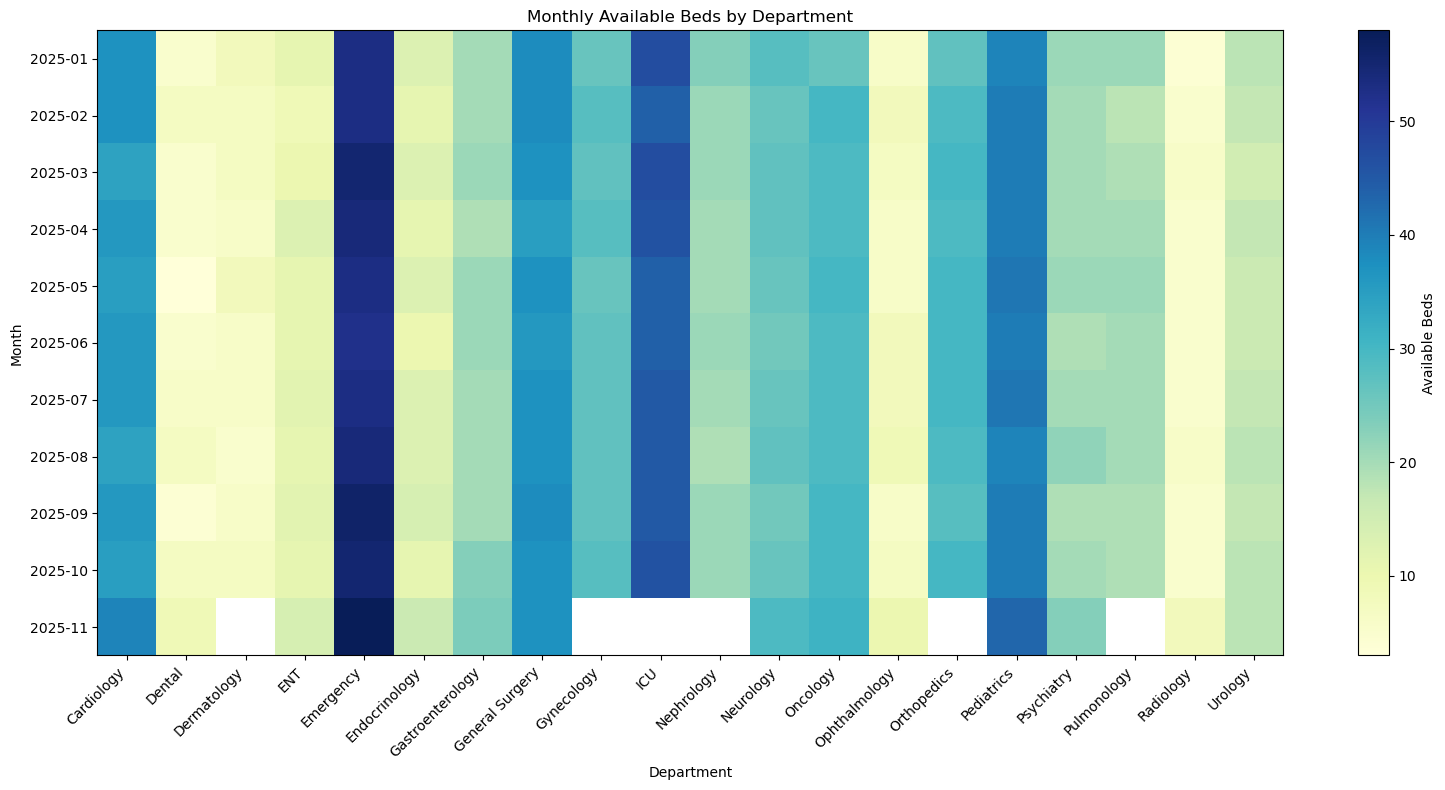

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Create month-wise and department-wise table
monthly_available = monthly_bed_analysis.pivot_table(
    index="Month",
    columns="department_name",
    values="Available_Beds",
    aggfunc="mean"
)

# Round values
monthly_available = monthly_available.round(0)

# Create heatmap using Matplotlib
plt.figure(figsize=(16, 8))

plt.imshow(
    monthly_available,
    aspect="auto",
    cmap="YlGnBu"
)

# X-axis: Departments
plt.xticks(
    range(len(monthly_available.columns)),
    monthly_available.columns,
    rotation=45,
    ha="right"
)

# Y-axis: Months
plt.yticks(
    range(len(monthly_available.index)),
    monthly_available.index
)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label("Available Beds")

plt.xlabel("Department")
plt.ylabel("Month")
plt.title("Monthly Available Beds by Department")

plt.tight_layout()
plt.show()

In [47]:

# Calculate occupancy rate for each month and department
monthly_bed_analysis["Occupancy_Rate"] = (
    monthly_bed_analysis["Average_Occupied_Beds"]
    / monthly_bed_analysis["Total_Beds"]
) * 100

# Identify near or over capacity departments
near_over_capacity = monthly_bed_analysis[
    monthly_bed_analysis["Occupancy_Rate"] >= 50
].copy()

# Add capacity status
near_over_capacity["Capacity_Status"] = near_over_capacity[
    "Occupancy_Rate"
].apply(
    lambda x: "Over Capacity" if x >= 100 else "Near Capacity"
)

# Sort from highest occupancy to lowest
near_over_capacity = near_over_capacity.sort_values(
    "Occupancy_Rate",
    ascending=False
)

# Display result
display(
    near_over_capacity[
        [
            "Month",
            "Department_ID",
            "department_name",
            "Total_Beds",
            "Average_Occupied_Beds",
            "Available_Beds",
            "Occupancy_Rate",
            "Capacity_Status"
        ]
    ]
)

,Month,Department_ID,department_name,Total_Beds,Average_Occupied_Beds,Available_Beds,Occupancy_Rate,Capacity_Status
99,2025-05,D020,Dental,10,7,3,70.0,Near Capacity
15,2025-01,D016,Radiology,10,6,4,60.0,Near Capacity
179,2025-09,D020,Dental,10,6,4,60.0,Near Capacity
177,2025-09,D018,Ophthalmology,12,6,6,50.0,Near Capacity
175,2025-09,D016,Radiology,10,5,5,50.0,Near Capacity
146,2025-08,D007,Dermatology,10,5,5,50.0,Near Capacity
135,2025-07,D016,Radiology,10,5,5,50.0,Near Capacity
119,2025-06,D020,Dental,10,5,5,50.0,Near Capacity
115,2025-06,D016,Radiology,10,5,5,50.0,Near Capacity
97,2025-05,D018,Ophthalmology,12,6,6,50.0,Near Capacity


In [48]:
# ==========================================
# departments Underutilzing beds
# ==========================================

# Overall average occupancy by department
department_occupancy = (
    monthly_bed_analysis
    .groupby("department_name")["Occupancy_Rate"]
    .mean()
    .reset_index()
)

# Classify underutilized departments
underutilized_departments = department_occupancy[
    department_occupancy["Occupancy_Rate"] < 40
].copy()

underutilized_departments["Status"] = "Underutilized"

underutilized_departments["Occupancy_Rate"] = (
    underutilized_departments["Occupancy_Rate"]
    .round(0)
    .astype(int)
)

display(
    underutilized_departments[
        ["department_name", "Occupancy_Rate", "Status"]
    ]
)

,department_name,Occupancy_Rate,Status
0,Cardiology,10,Underutilized
2,Dermatology,34,Underutilized
3,ENT,24,Underutilized
4,Emergency,10,Underutilized
5,Endocrinology,30,Underutilized
6,Gastroenterology,17,Underutilized
7,General Surgery,8,Underutilized
8,Gynecology,10,Underutilized
9,ICU,9,Underutilized
10,Nephrology,17,Underutilized


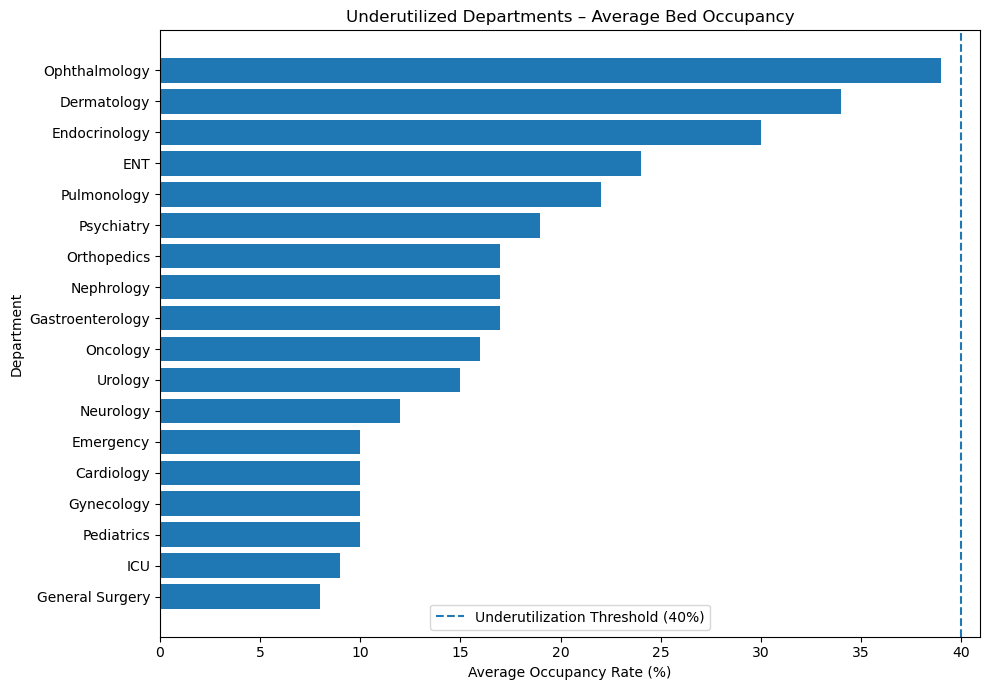

In [49]:
import matplotlib.pyplot as plt

# Sort departments from lowest to highest occupancy
plot_data = underutilized_departments.sort_values(
    "Occupancy_Rate",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["department_name"],
    plot_data["Occupancy_Rate"]
)

# Underutilization threshold
plt.axvline(
    40,
    linestyle="--",
    label="Underutilization Threshold (40%)"
)

plt.xlabel("Average Occupancy Rate (%)")
plt.ylabel("Department")
plt.title("Underutilized Departments – Average Bed Occupancy")

plt.legend()
plt.tight_layout()
plt.show()

In [50]:

# ==========================================
# near capacity depatments
# ==========================================
# Overall occupancy rate by department
department_occupancy = (
    monthly_bed_analysis
    .groupby(["Department_ID", "department_name"])
    .agg(
        Total_Beds=("Total_Beds", "first"),
        Average_Occupancy_Rate=("Occupancy_Rate", "mean")
    )
    .reset_index()
)

# Identify departments near or over capacity
near_over_capacity = department_occupancy[
    department_occupancy["Average_Occupancy_Rate"] >= 40
].copy()

# Classify capacity status
near_over_capacity["Capacity_Status"] = near_over_capacity[
    "Average_Occupancy_Rate"
].apply(
    lambda x: "Over Capacity" if x >= 100 else "Near Capacity"
)

# Round occupancy rate
near_over_capacity["Average_Occupancy_Rate"] = (
    near_over_capacity["Average_Occupancy_Rate"]
    .round(0)
    .astype(int)
)

# Sort highest occupancy first
near_over_capacity = near_over_capacity.sort_values(
    "Average_Occupancy_Rate",
    ascending=False
)

# Final output
display(
    near_over_capacity[
        [
            "Department_ID",
            "department_name",
            "Total_Beds",
            "Average_Occupancy_Rate",
            "Capacity_Status"
        ]
    ]
)

,Department_ID,department_name,Total_Beds,Average_Occupancy_Rate,Capacity_Status
15,D016,Radiology,10,46,Near Capacity
19,D020,Dental,10,43,Near Capacity


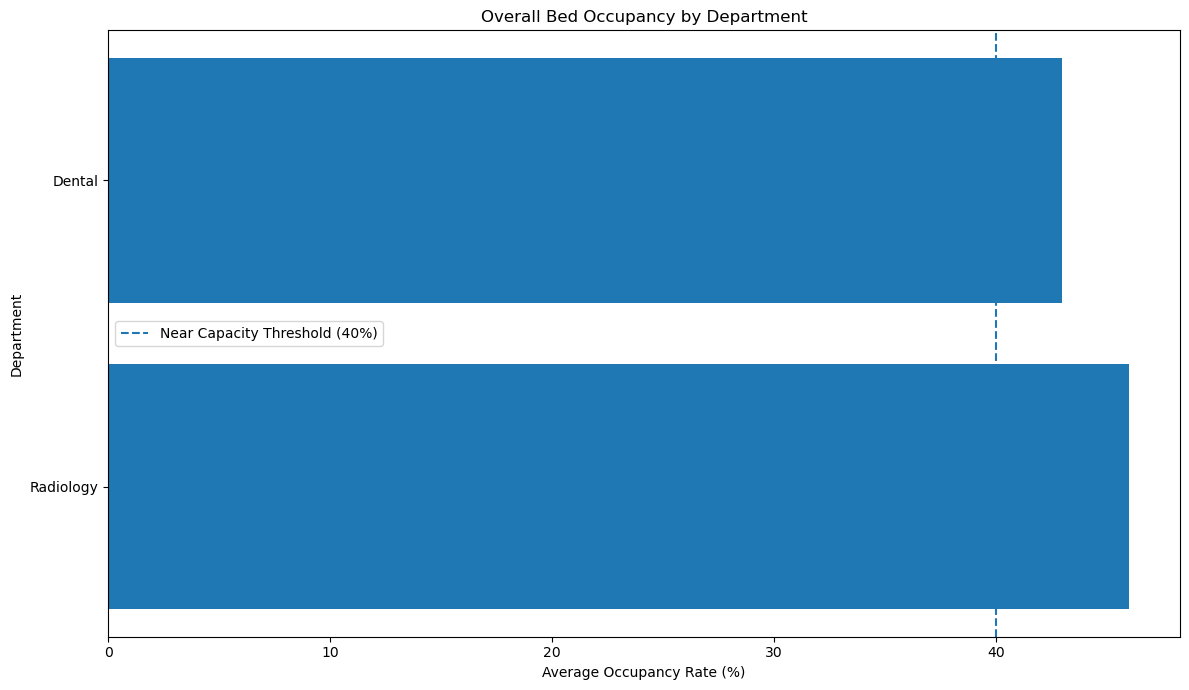

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.barh(
    near_over_capacity["department_name"],
    near_over_capacity["Average_Occupancy_Rate"]
)

# Threshold for near capacity
plt.axvline(
    x=40,
    linestyle="--",
    label="Near Capacity Threshold (40%)"
)

plt.xlabel("Average Occupancy Rate (%)")
plt.ylabel("Department")
plt.title("Overall Bed Occupancy by Department")

plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# ==========================================
# Peak and low months 
# ==========================================
monthly_overall = (
    monthly_bed_analysis
    .groupby("Month")
    .agg(
        Average_Occupied_Beds=("Average_Occupied_Beds", "mean"),
        Total_Beds=("Total_Beds", "sum")
    )
    .reset_index()
)

monthly_overall["Occupancy_Rate"] = (
    monthly_overall["Average_Occupied_Beds"]
    / monthly_overall["Total_Beds"]
) * 100

# Peak and lowest occupancy months
peak_month = monthly_overall.loc[
    monthly_overall["Occupancy_Rate"].idxmax()
]

lowest_month = monthly_overall.loc[
    monthly_overall["Occupancy_Rate"].idxmin()
]

print("Peak Occupancy Month:")
print(peak_month["Month"],
      "-", round(peak_month["Occupancy_Rate"], 0), "%")

print("\nLowest Occupancy Month:")
print(lowest_month["Month"],
      "-", round(lowest_month["Occupancy_Rate"], 0), "%")

Peak Occupancy Month:
2025-06 - 1.0 %

Lowest Occupancy Month:
2025-11 - 0.0 %


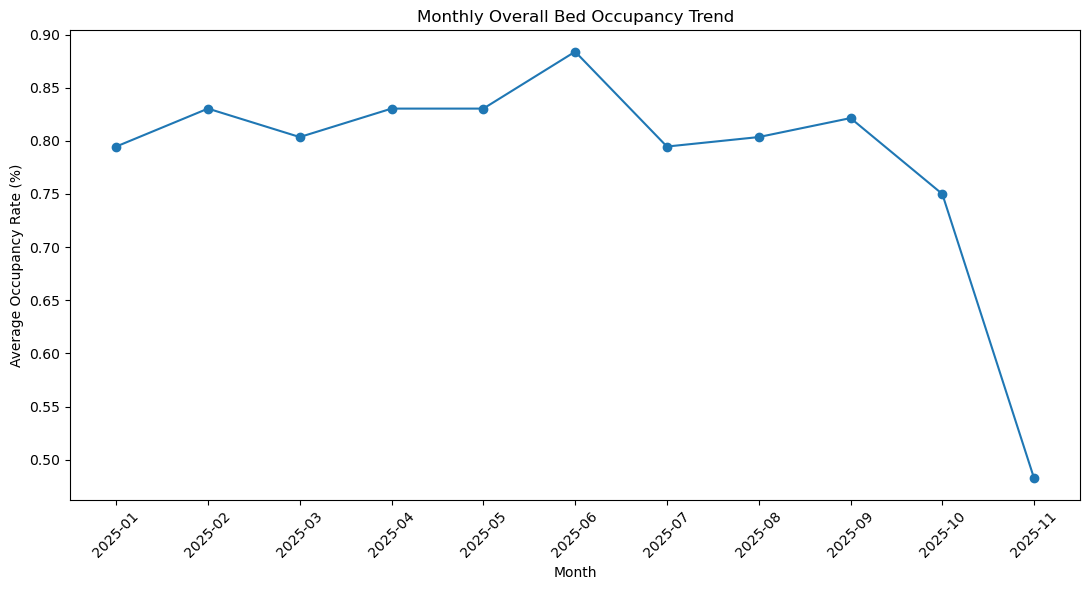

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.plot(
    monthly_overall["Month"].astype(str),
    monthly_overall["Occupancy_Rate"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Occupancy Rate (%)")
plt.title("Monthly Overall Bed Occupancy Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
# Department-wise consistency
department_consistency = (
    monthly_bed_analysis
    .groupby(["Department_ID", "department_name"])
    .agg(
        Average_Occupancy=("Occupancy_Rate", "mean"),
        Occupancy_Std=("Occupancy_Rate", "std")
    )
    .reset_index()
)

# Lower standard deviation = more consistent
# Sort by high occupancy first, then low variation
department_consistency = department_consistency.sort_values(
    ["Average_Occupancy", "Occupancy_Std"],
    ascending=[False, True]
)

# Round values
department_consistency["Average_Occupancy"] = (
    department_consistency["Average_Occupancy"]
    .round(0)
)

department_consistency["Occupancy_Std"] = (
    department_consistency["Occupancy_Std"]
    .round(1)
)

display(department_consistency)

,Department_ID,department_name,Average_Occupancy,Occupancy_Std
15,D016,Radiology,46.0,10.3
19,D020,Dental,43.0,16.8
17,D018,Ophthalmology,39.0,11.3
6,D007,Dermatology,34.0,9.7
18,D019,Endocrinology,30.0,9.4
5,D006,ENT,24.0,9.1
12,D013,Pulmonology,22.0,4.7
11,D012,Psychiatry,19.0,4.5
9,D010,Nephrology,17.0,4.2
13,D014,Gastroenterology,17.0,5.9


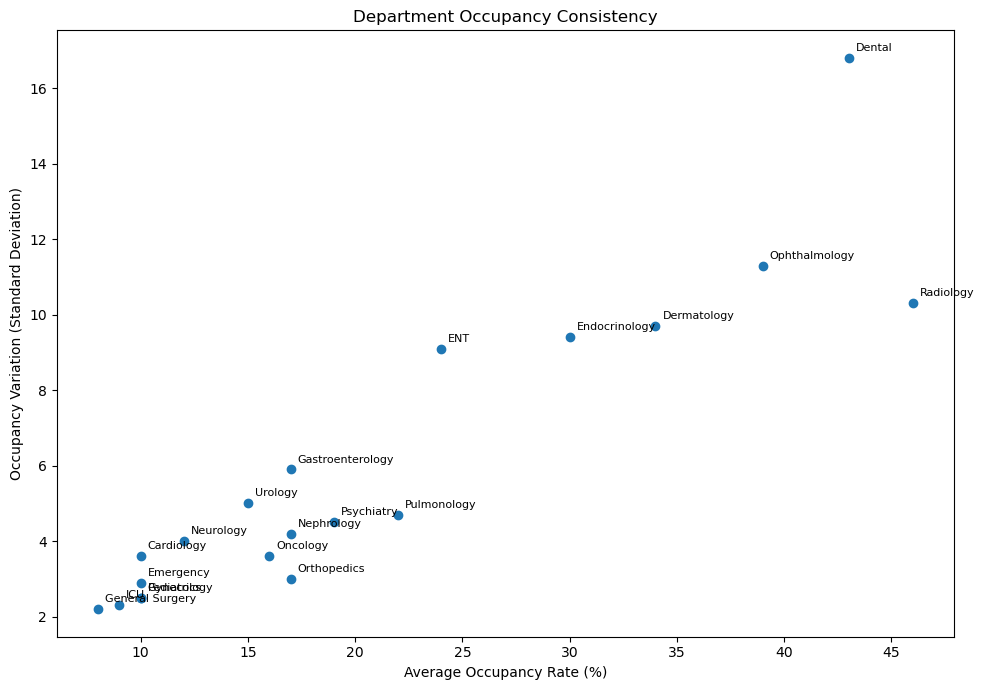

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    department_consistency["Average_Occupancy"],
    department_consistency["Occupancy_Std"]
)

# Add department names
for _, row in department_consistency.iterrows():
    plt.annotate(
        row["department_name"],
        (row["Average_Occupancy"], row["Occupancy_Std"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Average Occupancy Rate (%)")
plt.ylabel("Occupancy Variation (Standard Deviation)")
plt.title("Department Occupancy Consistency")

plt.tight_layout()
plt.show()

In [52]:
# ==========================================
# KPI SUMMARY - BED UTILIZATION & OCCUPANCY
# ==========================================

# 1. Overall average occupancy
overall_occupancy = monthly_bed_analysis["Occupancy_Rate"].mean()

# 2. Most utilized department
most_utilized = department_occupancy.loc[
    department_occupancy["Average_Occupancy_Rate"].idxmax()
]

# 3. Least utilized department
least_utilized = department_occupancy.loc[
    department_occupancy["Average_Occupancy_Rate"].idxmin()
]

# 4. Average available beds
average_available_beds = monthly_bed_analysis["Available_Beds"].mean()

# 5. Peak occupancy month
peak_month = monthly_overall.loc[
    monthly_overall["Occupancy_Rate"].idxmax()
]

# Display KPIs
print("========== KPI SUMMARY ==========")

print(
    f"Average Occupancy Rate : "
    f"{overall_occupancy:.0f}%"
)

print(
    f"Most Utilized Department : "
    f"{most_utilized['department_name']} "
    f"({most_utilized['Average_Occupancy_Rate']:.0f}%)"
)

print(
    f"Least Utilized Department : "
    f"{least_utilized['department_name']} "
    f"({least_utilized['Average_Occupancy_Rate']:.0f}%)"
)

print(
    f"Average Available Beds : "
    f"{average_available_beds:.0f}"
)

print(
    f"Peak Occupancy Month : "
    f"{peak_month['Month']} "
    f"({peak_month['Occupancy_Rate']:.0f}%)"
)

========== KPI SUMMARY ==========
Average Occupancy Rate : 20%
Most Utilized Department : Radiology (46%)
Least Utilized Department : General Surgery (8%)
Average Available Beds : 24
Peak Occupancy Month : 2025-06 (1%)
